# DV contrast across the shape ladder, with complex constituents — *criterion corrected*

**The bug.** The previous version of this comparison reported that even in the needle limit a
composite needs real contrast $r=\varepsilon_b/\varepsilon_a\gtrsim20.5$ before DV angles appear.
Chapter 4 puts the columnar limit at $r^\ast=17.95$. Both numbers came out of correct code; they
answer *different questions*, and the earlier figure silently mixed them.

The earlier feasibility test imposed, on top of DV existence, a **confinement cut**
$\Delta_{\mathcal B}<10\lambda_0$ — solutions whose field leaks more than ten free-space wavelengths
into the partnering medium were discarded as "not really a surface wave". Chapter 4 imposed no such
cut: its $r^\ast$ was the crossing of $\gamma=\varepsilon^t_{\mathcal A}/\varepsilon^s_{\mathcal A}=3$,
pure existence. The cut inflates the needle-limit threshold by **+14%** ($17.97\to20.53$) and the
$c/a=5$ thresholds by **17–19%**, *unevenly across shape families* — so the superspheroid comparison
inherited a shape-dependent bias on top of the offset.

**The fix, implemented here.** Pure existence is the primary criterion everywhere in this notebook,
so that the real-axis intercept of every complex-plane boundary reproduces the Chapter 4 $r^\ast$
table exactly (§3). The confinement cut is demoted to a declared sensitivity study (§7), where it
belongs. Only then is the saving bought by the imaginary part meaningful (§5–§6), because it is
measured against the same baseline the previous chapter used.

| criterion | statement | needle-limit threshold | used by |
|---|---|---|---|
| **C1** | $\gamma_{\rm HCM}=\varepsilon^t_{\mathcal A}/\varepsilon^s_{\mathcal A}>3$ | $17.946$ | Chapter 4 (lossless only) |
| **C2** | $\exists\,\psi\in(0,\tfrac\pi2)$ and passive dielectric $\varepsilon_{\mathcal B}$ with decay on both sides | $17.975$ | **this notebook** (generalizes to complex) |
| **C3** | C2 **and** $\Delta_{\mathcal B}<10\lambda_0$ | $20.525$ | the earlier figure — *withdrawn* |

C1 and C2 are equivalent for lossless constituents (§2.5); they differ here only by the resolution of
the $\psi$ grid, $0.16\%$. C2 is the one that survives complex $\varepsilon$, where the ordering
statement C1 has no meaning.

Reference: Mackay, Zhou & Lakhtakia, *Dyakonov–Voigt surface waves*, Proc. R. Soc. A **475** (2019) 20190317.

**Notation.** $\varepsilon^t_{\mathcal A}$ is the HCM permittivity **along** the optic axis (the
particle symmetry axis), $\varepsilon^s_{\mathcal A}$ transverse — the DV paper's convention. This is
the same ratio Chapter 4 calls $\gamma=\varepsilon_z/\varepsilon_t$. Particles have bounding aspect
ratio $c/a=1/\alpha$; $\alpha=0.001$ is the needle/columnar limit, $\alpha=0.2$ is $c/a=5$.
$\exp(-i\omega t)$, so passive means $\mathrm{Im}\,\varepsilon>0$. Constituents are
$\varepsilon_a=1$ (void) at volume fraction $f$ and $\varepsilon_b$ (host) at $1-f$; contrast
$r=\varepsilon_b/\varepsilon_a$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

np.seterr(divide='ignore', invalid='ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

---
## 1. Machinery

Self-contained: the superspheroid depolarization ladder of the Chapter 4 notebook, the anisotropic
Bruggeman solver, and the DV dispersion relation of the contrast notebook, with the feasibility test
now defaulting to **pure existence** (`db_max=np.inf`).

### 1.1 Depolarization

Particles are the superspheroid family
$\big(|x/a|^{2m}+|y/a|^{2m}\big)^{n/m}+|z/c|^{2n}=1$: $(m,n)=(1,1)$ is the spheroid,
$(2,2)\to$ square prism as $m\to\infty$, $(1,2)\to$ circular cylinder as $n\to\infty$. For the
spheroid the depolarization dyadic is evaluated by its exact one-dimensional quadrature; for the rest
via the transverse factor $L_t(\gamma)$ of the superspheroid homogenization paper, with
$\mathrm{tr}\,\underline{\underline L}=1/\gamma$ giving
$D_{\rm ax}=(1-2\gamma L_t)/\varepsilon^t$, $D_{\rm tr}=\gamma L_t/\varepsilon^s$. The sum rule
$\varepsilon^t D_{\rm ax}+2\varepsilon^s D_{\rm tr}=1$ is checked in §2.

In [2]:
_NG = 400
_xg, _wg = np.polynomial.legendre.leggauss(_NG)
_u = 0.5 * (_xg + 1.0)
_w = 0.5 * _wg


def _quad01(N):
    xg, wg = np.polynomial.legendre.leggauss(N)
    v = 0.5 * (xg + 1.0)
    return np.sin(0.5 * np.pi * v) ** 2, 0.5 * wg * 0.5 * np.pi * np.sin(np.pi * v)


def depolarization_spheroid(eps_ax, eps_tr, aspect):
    '''(D_ax, D_tr) for a spheroid of bounding aspect ratio c/a, det U = 1.'''
    eps_ax = np.atleast_1d(np.asarray(eps_ax, complex))
    eps_tr = np.atleast_1d(np.asarray(eps_tr, complex))
    Ux2, Ut2 = aspect ** (4.0 / 3.0), aspect ** (-2.0 / 3.0)
    A = eps_ax[:, None] / Ux2
    B = eps_tr[:, None] / Ut2
    denom = B + (A - B) * _u[None, :] ** 2
    Dax = np.sum(_w[None, :] * _u[None, :] ** 2 / denom, axis=1) / Ux2
    Dtr = np.sum(_w[None, :] * (1.0 - _u[None, :] ** 2) / denom, axis=1) / (2.0 * Ut2)
    return Dax, Dtr


_SS_CACHE = {}


def ss_order(c):
    '''Quadrature order for the superspheroid double integral (see §2.2 convergence check).'''
    return 32 if c <= 20.0 else 64


def Lt_superspheroid(gamma, c, m, n, a=1.0, N=None):
    gamma = np.atleast_1d(np.asarray(gamma, dtype=complex))
    N = ss_order(c) if N is None else N
    key = (m, n, N, a, c)
    if key not in _SS_CACHE:
        t, w = _quad01(N)
        S, T = np.meshgrid(t, t, indexing='ij')
        W = np.outer(w, w).ravel()
        s, tau = S.ravel(), T.ravel()
        A = 1 - tau ** (2 * n)
        B = 1 - s ** (2 * m)
        x = a * A ** (1 / (2 * m)) * B ** (1 / (2 * m))
        y = a * A ** (1 / (2 * m)) * s
        z = c * tau
        F = a * a * c * A ** (1 / m) * B ** (1 / (2 * m))
        _SS_CACHE[key] = (W, x * x + y * y, z * z, F)
    W, rho2, z2, F = _SS_CACHE[key]
    R2 = gamma[:, None] * rho2[None, :] + z2[None, :]
    return (2.0 / np.pi) * np.sum(W[None, :] * F[None, :] / (R2 * np.sqrt(R2)), axis=1)


def Lt_cylinder(gamma, c, a=1.0):
    g = np.atleast_1d(np.asarray(gamma, complex))
    return c / (2 * g * np.sqrt(a * a * g + c * c))


def Lt_cuboid(gamma, c, a=1.0):
    g = np.atleast_1d(np.asarray(gamma, complex))
    rg = np.sqrt(g)
    return 2 / (np.pi * g) * (np.arctan(a * rg / c)
                              + np.arctan((-2 * a * rg + np.sqrt(2 * a * a * g + c * c)) / c))


def Lt_of(shape, gamma, c):
    if shape == 'cylinder':
        return Lt_cylinder(gamma, c)
    if shape == 'cuboid':
        return Lt_cuboid(gamma, c)
    m, n = shape
    return Lt_superspheroid(gamma, c, m, n)


def depolarization(shape, eps_ax, eps_tr, c):
    if shape == (1, 1):
        return depolarization_spheroid(eps_ax, eps_tr, c)
    eps_ax = np.atleast_1d(np.asarray(eps_ax, complex))
    eps_tr = np.atleast_1d(np.asarray(eps_tr, complex))
    g = eps_ax / eps_tr
    Lt = Lt_of(shape, g, c)
    return (1 - 2 * g * Lt) / eps_ax, g * Lt / eps_tr

### 1.2 Bruggeman

$\sum_\ell f_\ell\,\underline{\underline a}_\ell=0$ is diagonal for identically oriented particles of
one shape, so for each axis $j$

$$f\,\frac{\varepsilon_a-\varepsilon_j}{1+D_j(\varepsilon_a-\varepsilon_j)}
+(1-f)\,\frac{\varepsilon_b-\varepsilon_j}{1+D_j(\varepsilon_b-\varepsilon_j)}=0,$$

with $D_j$ evaluated *in* the HCM. Damped fixed point, seeded on the volume average — the branch
continuous with $\langle\varepsilon\rangle$ as the shape dilutes. The residual of the equation above
is returned and gated on downstream.

In [3]:
FS_DEFAULT = np.arange(0.40, 0.9251, 0.0125)     # void fraction; optimum sits near 0.71
PSIS_DEFAULT = np.radians(np.linspace(0.2, 89.8, 700))


def bruggeman(eps_a, eps_b, fs, shape=(1, 1), c=1000.0, tol=1e-12, itmax=4000, damp=0.5):
    fs = np.atleast_1d(np.asarray(fs, float))
    ea, eb = complex(eps_a), complex(eps_b)
    et = es = (fs * ea + (1 - fs) * eb).astype(complex)
    for _ in range(itmax):
        Dax, Dtr = depolarization(shape, et, es, c)
        new = []
        for D, e in ((Dax, et), (Dtr, es)):
            da, db = 1.0 + D * (ea - e), 1.0 + D * (eb - e)
            new.append((fs * ea / da + (1 - fs) * eb / db) / (fs / da + (1 - fs) / db))
        etn, esn = new
        step = max(np.max(np.abs(etn - et)), np.max(np.abs(esn - es)))
        et, es = et + damp * (etn - et), es + damp * (esn - es)
        if step < tol:
            break
    Dax, Dtr = depolarization(shape, et, es, c)
    res = 0.0
    for D, e in ((Dax, et), (Dtr, es)):
        res = max(res, float(np.max(np.abs(
            fs * (ea - e) / (1 + D * (ea - e)) + (1 - fs) * (eb - e) / (1 + D * (eb - e))))))
    return et, es, res

### 1.3 DV dispersion relation and the feasibility test

Equation (2.29) of the paper, isolated and squared into a quadratic in $\varepsilon_{\mathcal B}$;
the spurious root is rejected by substitution back into the unsquared equation, and the branches of
both radicals are fixed by requiring decay on each side.

A configuration **generates a DV angle** (criterion **C2**) when some real $\psi\in(0,\pi/2)$ admits an
$\varepsilon_{\mathcal B}$ that is a dielectric ($\mathrm{Re}\,\varepsilon_{\mathcal B}>0$), passive
($\mathrm{Im}\,\varepsilon_{\mathcal B}\ge0$) and decaying ($\Delta_{\mathcal B}$ finite). Setting
`db_max` finite adds criterion **C3**'s confinement requirement; the default `np.inf` is C2.

In [4]:
def _sqrt_pos_real(z):
    s = np.sqrt(np.asarray(z, dtype=complex))
    return np.where(s.real > 0, s, -s)


def dv_solutions(es, et, psis):
    '''Both eps_B roots of the DV dispersion relation, vectorised over psi.'''
    psis = np.atleast_1d(np.asarray(psis, dtype=float))
    cot = 1.0 / np.tan(psis)
    c2 = cot ** 2
    K = c2 * (es + et) ** 2
    A, Bc, Cc = 4 * es, 4 * es ** 2 - 4 * es * et + K, -es * (4 * es * et + K)
    disc = np.sqrt(Bc * Bc - 4 * A * Cc + 0j)
    sA = complex(_sqrt_pos_real(es))
    q = sA / np.cos(psis)
    aA_im = (1j * sA * np.tan(psis)).imag
    L = np.where(abs(q.imag) < 1e-13, np.inf, 1.0 / (2 * np.pi * np.maximum(q.imag, 1e-300)))
    for sgn in (+1, -1):
        eB = (-Bc + sgn * disc) / (2 * A)
        sB = _sqrt_pos_real(es / np.cos(psis) ** 2 - eB)
        res = 2 * (es + eB) * (es + sA * cot * sB) + (es - eB) * (es + et) * c2
        scale = np.abs(2 * (es + eB) * es) + np.abs((es - eB) * (es + et) * c2) + 1e-30
        yield dict(psi=psis, eB=eB, ok=(np.abs(res) / scale < 1e-8) & (aA_im > 0) & (sB.real > 0),
                   dA=1.0 / (2 * np.pi * aA_im), dB=1.0 / (2 * np.pi * sB.real), L=L)


def dv_feasible(es, et, psis=PSIS_DEFAULT, db_max=np.inf):
    '''Best (most tightly bound) admissible DV solution for one medium A, or None.'''
    best = None
    for sol in dv_solutions(es, et, psis):
        m = (sol['ok'] & (sol['eB'].real > 0) & (sol['eB'].imag >= -1e-9)
             & (sol['dB'] < db_max) & np.isfinite(sol['dB']))
        if not m.any():
            continue
        idx = np.flatnonzero(m)
        k = idx[np.argmin(sol['dB'][idx])]
        rec = dict(psi_deg=np.degrees(sol['psi'][k]), eB=sol['eB'][k], dA=sol['dA'][k],
                   dB=sol['dB'][k], L=sol['L'][k], psi_lo=np.degrees(sol['psi'][idx].min()),
                   psi_hi=np.degrees(sol['psi'][idx].max()))
        if best is None or rec['dB'] < best['dB']:
            best = rec
    return best


def composite_feasible(eps_a, eps_b, shape=(1, 1), c=1000.0, fs=FS_DEFAULT,
                       db_max=np.inf, psis=PSIS_DEFAULT):
    '''Best DV solution the composite can offer over volume fraction, or None.'''
    et, es, res = bruggeman(eps_a, eps_b, fs, shape, c)
    if res > 1e-8:
        return None
    best = None
    for j in range(len(fs)):
        rec = dv_feasible(es[j], et[j], psis=psis, db_max=db_max)
        if rec is None:
            continue
        rec = dict(rec, f=fs[j], eps_ax=et[j], eps_tr=es[j])
        if best is None or rec['dB'] < best['dB']:
            best = rec
    return best


def gamma_max(eps_b, eps_a=1.0, shape=(1, 1), c=1000.0, fs=FS_DEFAULT):
    '''C1: best achievable eps_ax/eps_tr over volume fraction (real constituents).'''
    et, es, _ = bruggeman(eps_a, eps_b, fs, shape, c)
    return float(np.max(et.real / es.real))


def rstar_C1(shape=(1, 1), c=1000.0, lo=8.0, hi=90.0):
    '''Chapter-4 route: contrast at which max_f gamma crosses 3.'''
    return float(brentq(lambda x: gamma_max(x, shape=shape, c=c) - 3.0, lo, hi, xtol=1e-3))


def rstar_C2(shape=(1, 1), c=1000.0, db_max=np.inf, lo=8.0, hi=120.0, tol=2e-3):
    '''DV route: least real eps_b admitting a DV angle (db_max=inf -> C2, finite -> C3).'''
    if composite_feasible(1.0, complex(hi, 0), shape, c, db_max=db_max) is None:
        return np.nan
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if composite_feasible(1.0, complex(mid, 0), shape, c, db_max=db_max) is None:
            lo = mid
        else:
            hi = mid
    return hi


def boundary_im(re, shape, c, rstar, db_max=np.inf, tol=1e-2):
    '''Least Im(eps_b) admitting a DV angle at fixed Re(eps_b).

    Bracketed on the near-circular prediction |eps_b| ~ r*, then bisected.  The
    single-crossing assumption this makes is verified against a brute-force scan in §2.6.'''
    if re >= rstar:
        return 0.0
    hi = max(1.05 * np.sqrt(max(rstar ** 2 - re ** 2, 0.0)), 0.5)
    for _ in range(9):
        if composite_feasible(1.0, complex(re, hi), shape, c, db_max=db_max) is not None:
            break
        hi *= 1.6
    else:
        return np.nan
    lo = 0.0
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if composite_feasible(1.0, complex(re, mid), shape, c, db_max=db_max) is None:
            lo = mid
        else:
            hi = mid
    return hi

---
## 2. Validation

Unchanged from the earlier notebooks except for §2.5–2.6, which are the checks the earlier version
lacked and which would have caught the bug.

In [5]:
print('2.1  sum rule  eps_ax*D_ax + 2*eps_tr*D_tr = 1')
for et, es, c, shape in [(3 + 0.4j, 2 + 0j, 4.0, (1, 1)), (15 + 2j, 3 + 1j, 25.0, (1, 1)),
                         (6 + 1j, 2 + 0.3j, 5.0, (1, 2)), (6 + 1j, 2 + 0.3j, 5.0, 'cuboid'),
                         (6 + 1j, 2 + 0.3j, 5.0, 'cylinder')]:
    Dax, Dtr = depolarization(shape, [et], [es], c)
    val = et * Dax[0] + 2 * es * Dtr[0]
    print(f'    {str(shape):10s} c/a={c:<6g} -> {val:.10f}')
    assert abs(val - 1) < 3e-6

print('\n2.2  superspheroid quadrature convergence at c/a = 1000 (order used there: 64)')
_ss_order_default = ss_order
for N in (32, 48, 64, 96):
    _SS_CACHE.clear()
    ss_order = (lambda c, N=N: N)
    print(f'    N={N:3d}  r*(C1, type (i) m=2) = {rstar_C1(shape=(2, 2), c=1000.0):8.4f}')
ss_order = _ss_order_default
_SS_CACHE.clear()
print('    (N=32 is 0.4% high, N=64 is converged; the sweep uses 32 for c/a<=20, 64 above)')

2.1  sum rule  eps_ax*D_ax + 2*eps_tr*D_tr = 1
    (1, 1)     c/a=4      -> 1.0000000000+0.0000000000j
    (1, 1)     c/a=25     -> 1.0000000000+0.0000000000j
    (1, 2)     c/a=5      -> 1.0000000000-0.0000000000j
    cuboid     c/a=5      -> 1.0000000000+0.0000000000j
    cylinder   c/a=5      -> 1.0000000000+0.0000000000j

2.2  superspheroid quadrature convergence at c/a = 1000 (order used there: 64)


    N= 32  r*(C1, type (i) m=2) =  18.0254


    N= 48  r*(C1, type (i) m=2) =  17.9426


    N= 64  r*(C1, type (i) m=2) =  17.9450


    N= 96  r*(C1, type (i) m=2) =  17.9450
    (N=32 is 0.4% high, N=64 is converged; the sweep uses 32 for c/a<=20, 64 above)


In [6]:
print('2.3  Bruggeman limits')
ea, eb, f = 1.0, 15.0, 0.4
et, es, _ = bruggeman(ea, eb, [f], (1, 1), 1.0)
ref = brentq(lambda e: f * (ea - e) / (ea + 2 * e) + (1 - f) * (eb - e) / (eb + 2 * e), 0.1, 20)
print(f'    spheres  -> isotropic {et[0].real:.8f} / {es[0].real:.8f}   classic Bruggeman {ref:.8f}')
assert abs(et[0] - es[0]) < 1e-9 and abs(et[0].real - ref) < 1e-7
for f in (0.5, 0.7):
    et, es, _ = bruggeman(1.0, 15.0, [f], (1, 1), 400.0)
    ref_t = f * 1 + (1 - f) * 15
    ref_s = brentq(lambda e: f * (1 - e) / (1 + e) + (1 - f) * (15 - e) / (15 + e), 0.1, 20)
    print(f'    needles f={f}: eps_ax={et[0].real:.5f} (linear avg {ref_t:.5f})   '
          f'eps_tr={es[0].real:.5f} (2-D Bruggeman {ref_s:.5f})')
    assert abs(et[0].real - ref_t) < 3e-3 and abs(es[0].real - ref_s) < 3e-3


def psi_closed_form(es, et, eB):
    c2 = 4 * es * (et - eB) * (es + eB) / ((eB - es) * (es + et) ** 2)
    return np.degrees(np.arctan(1 / np.sqrt(c2)))


print('\n2.4  DV angles quoted in the paper (figs. 4, 6, 7)')
for es, et, eB, paper in [(2, 6.5, 2.15, 15.32), (1, 5.3, 2.15, 47.00), (1.5, 5.8, 2.15, 33.36),
                          (1, 6.5, 2.75, 52.91), (2, 6.5, 2.25, 19.47)]:
    got = psi_closed_form(es, et, eB)
    print(f'    eps_s={es:<5} eps_t={et:<5} eps_B={eB:<6} -> psi={got:7.3f} deg   (paper {paper})')
    assert abs(got - paper) < 0.01

2.3  Bruggeman limits
    spheres  -> isotropic 7.14908526 / 7.14908526   classic Bruggeman 7.14908526
    needles f=0.5: eps_ax=7.99958 (linear avg 8.00000)   eps_tr=3.87326 (2-D Bruggeman 3.87298)
    needles f=0.7: eps_ax=5.19933 (linear avg 5.20000)   eps_tr=1.97923 (2-D Bruggeman 1.97912)

2.4  DV angles quoted in the paper (figs. 4, 6, 7)
    eps_s=2     eps_t=6.5   eps_B=2.15   -> psi= 15.320 deg   (paper 15.32)
    eps_s=1     eps_t=5.3   eps_B=2.15   -> psi= 47.000 deg   (paper 47.0)
    eps_s=1.5   eps_t=5.8   eps_B=2.15   -> psi= 33.356 deg   (paper 33.36)
    eps_s=1     eps_t=6.5   eps_B=2.75   -> psi= 52.913 deg   (paper 52.91)
    eps_s=2     eps_t=6.5   eps_B=2.25   -> psi= 19.471 deg   (paper 19.47)


### 2.5 The check that would have caught the bug

C1 and C2 must coincide for lossless constituents: the paper's inequalities (2.35) reduce, once
$\varepsilon_{\mathcal B}$ is free, to $\varepsilon^t_{\mathcal A}>3\varepsilon^s_{\mathcal A}$ and
nothing else. Any gap between the two routes is numerical, not physical. C3 is a *different*
criterion and is expected to disagree — the failure was to notice which one the figure was using.

In [7]:
print('needle limit, spheroid, eps_a = 1:')
c1 = rstar_C1(shape=(1, 1), c=1000.0)
c2 = rstar_C2(shape=(1, 1), c=1000.0, db_max=np.inf)
c3 = rstar_C2(shape=(1, 1), c=1000.0, db_max=10.0)
print(f'    C1  gamma = 3 crossing (Chapter 4)          r* = {c1:7.3f}')
print(f'    C2  DV existence, no confinement cut        r* = {c2:7.3f}   ({100*(c2/c1-1):+.2f}% vs C1)')
print(f'    C3  DV existence and Delta_B < 10 lambda_0  r* = {c3:7.3f}   ({100*(c3/c1-1):+.2f}% vs C1)')
print(f'\n    Chapter 4 columnar limit                    r* = 17.95')
print(f'    the number the earlier figure reported      r* = 20.5   <- this is C3, not C1')
assert abs(c2 / c1 - 1) < 0.005, 'C1 and C2 must agree for lossless constituents'

needle limit, spheroid, eps_a = 1:


    C1  gamma = 3 crossing (Chapter 4)          r* =  17.946
    C2  DV existence, no confinement cut        r* =  17.977   (+0.17% vs C1)
    C3  DV existence and Delta_B < 10 lambda_0  r* =  20.525   (+14.37% vs C1)

    Chapter 4 columnar limit                    r* = 17.95
    the number the earlier figure reported      r* = 20.5   <- this is C3, not C1


The $0.16\%$ gap between C1 and C2 is the $\psi$ grid: at the onset the admissible window
$\varepsilon^s_{\mathcal A}<\varepsilon_{\mathcal B}<(\varepsilon^t_{\mathcal A}-\varepsilon^s_{\mathcal A})/2$
closes to zero measure, so a discrete scan finds the first solution marginally late. It is the floor
on every C2 number below and is an order of magnitude smaller than the effect being measured.

### 2.6 Bracket control for the complex boundary

`boundary_im` assumes feasibility switches on once and stays on as $\mathrm{Im}\,\varepsilon_b$
grows. Brute-force scans confirm the single crossing at four representative points (41-point scans,
run at build time):

| $\alpha$ | shape | $\mathrm{Re}\,\varepsilon_b$ | single crossing | coarse first-feasible | bisected boundary |
|---|---|---|---|---|---|
| 0.001 | spheroid | 4 | yes | 17.41 | 16.94 |
| 0.001 | spheroid | 12 | yes | 13.48 | 13.22 |
| 0.2 | spheroid | 8 | yes | 26.70 | 25.87 |
| 0.2 | cylinder | 15 | yes | 15.85 | 15.25 |

(The coarse value overshoots by up to one scan step, as it must; the bisected value is the boundary.
The $\mathrm{Re}=15$ row is off the sweep grid and was bisected separately for this check.)

---
## 3. Reconciliation with Chapter 4

The sweep below is the expensive part (~12 min single-core), so it is cached. `RECOMPUTE = True`
regenerates it with the functions defined above.

In [8]:
DATA = {
  're_grid': [1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0],
  'rstar_g3': {
    '0.001|cuboid (m->inf)': 17.9449,
    '0.001|cylinder (n->inf)': 17.9449,
    '0.001|spheroid': 17.9458,
    '0.001|type (i) m=2': 17.9450,
    '0.001|type (ii) n=2': 17.9450,
    '0.2|cuboid (m->inf)': 23.3163,
    '0.2|cylinder (n->inf)': 22.0151,
    '0.2|spheroid': 29.4159,
    '0.2|type (i) m=2': 24.9162,
    '0.2|type (ii) n=2': 25.1746,
  },
  'rstar_dv': {
    '0.001|cuboid (m->inf)': 17.9597,
    '0.001|cylinder (n->inf)': 17.9647,
    '0.001|spheroid': 17.9747,
    '0.001|type (i) m=2': 17.9760,
    '0.001|type (ii) n=2': 17.9835,
    '0.2|cuboid (m->inf)': 23.3637,
    '0.2|cylinder (n->inf)': 22.0550,
    '0.2|spheroid': 29.4609,
    '0.2|type (i) m=2': 24.9728,
    '0.2|type (ii) n=2': 25.2318,
  },
  'boundary': {
    '0.001|cuboid (m->inf)': [17.100, 17.113, 17.112, 17.068, 16.939, 16.490, 15.762, 14.708, 13.222, 11.172, 8.122, 5.755, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.001|cylinder (n->inf)': [17.105, 17.117, 17.116, 17.063, 16.944, 16.495, 15.760, 14.706, 13.222, 11.174, 8.125, 5.759, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.001|spheroid': [17.105, 17.118, 17.117, 17.064, 16.945, 16.497, 15.762, 14.703, 13.221, 11.172, 8.130, 5.759, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.001|type (i) m=2': [17.116, 17.128, 17.127, 17.074, 16.946, 16.498, 15.764, 14.704, 13.223, 11.174, 8.124, 5.757, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.001|type (ii) n=2': [17.132, 17.135, 17.135, 17.082, 16.953, 16.497, 15.764, 14.706, 13.226, 11.175, 8.124, 5.750, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.2|cuboid (m->inf)': [19.597, 19.706, 19.799, 19.939, 20.021, 19.987, 19.723, 19.221, 18.433, 17.358, 15.939, 15.045, 14.021, 12.833, 11.418, 9.702, 7.428, 3.706, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.2|cylinder (n->inf)': [18.892, 18.981, 19.059, 19.162, 19.210, 19.091, 18.741, 18.136, 17.229, 15.998, 14.359, 13.320, 12.108, 10.657, 8.856, 6.399, 0.983, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.2|spheroid': [25.497, 25.599, 25.686, 25.837, 25.934, 25.997, 25.868, 25.531, 25.010, 24.301, 23.349, 22.772, 22.133, 21.425, 20.640, 19.768, 18.801, 17.708, 16.443, 15.016, 13.347, 11.337, 8.775, 4.838],
    '0.2|type (i) m=2': [21.013, 21.126, 21.230, 21.392, 21.479, 21.489, 21.280, 20.842, 20.149, 19.201, 17.950, 17.173, 16.303, 15.305, 14.161, 12.825, 11.232, 9.227, 6.469, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.2|type (ii) n=2': [21.347, 21.462, 21.561, 21.720, 21.803, 21.807, 21.605, 21.171, 20.483, 19.544, 18.310, 17.551, 16.689, 15.713, 14.599, 13.310, 11.775, 9.873, 7.346, 2.911, 0.000, 0.000, 0.000, 0.000],
  },
  'boundary_cut': {
    '0.001|spheroid': [18.578, 18.629, 18.663, 18.676, 18.625, 18.356, 17.841, 17.056, 15.939, 14.452, 12.458, 11.162, 9.588, 7.563, 4.503, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    '0.2|spheroid': [29.155, 29.292, 29.414, 29.639, 29.820, 30.031, 30.057, 29.929, 29.656, 29.202, 28.557, 28.167, 27.725, 27.245, 26.708, 26.126, 25.486, 24.763, 23.966, 23.088, 22.132, 21.074, 19.910, 18.621],
  },
  'rstar_cut': {
    '0.001|cuboid (m->inf)': {'2.0': 26.137, '5.0': 22.147, '10.0': 20.525, '50.0': 18.801, 'inf': 17.960},
    '0.001|cylinder (n->inf)': {'2.0': 26.137, '5.0': 22.147, '10.0': 20.525, '50.0': 18.801, 'inf': 17.965},
    '0.001|spheroid': {'2.0': 26.139, '5.0': 22.149, '10.0': 20.525, '50.0': 18.802, 'inf': 17.975},
    '0.001|type (i) m=2': {'2.0': 26.137, '5.0': 22.147, '10.0': 20.525, '50.0': 18.802, 'inf': 17.976},
    '0.001|type (ii) n=2': {'2.0': 26.137, '5.0': 22.147, '10.0': 20.525, '50.0': 18.802, 'inf': 17.983},
    '0.2|cuboid (m->inf)': {'2.0': 37.042, '5.0': 30.123, '10.0': 27.436, '50.0': 24.661, 'inf': 23.364},
    '0.2|cylinder (n->inf)': {'2.0': 34.323, '5.0': 28.157, '10.0': 25.738, '50.0': 23.236, 'inf': 22.055},
    '0.2|spheroid': {'2.0': 48.014, '5.0': 38.575, '10.0': 34.944, '50.0': 31.223, 'inf': 29.461},
    '0.2|type (i) m=2': {'2.0': 40.047, '5.0': 32.389, '10.0': 29.449, '50.0': 26.396, 'inf': 24.973},
    '0.2|type (ii) n=2': {'2.0': 40.450, '5.0': 32.724, '10.0': 29.755, '50.0': 26.671, 'inf': 25.232},
  },
  'dB_boundary': {
    '0.001|cuboid (m->inf)': [72.3, 75.3, 77.8, 81.4, 89.7, 108.8, 135.0, 177.6, 261.8, 452.9, 1140.1, 2763.4, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|cylinder (n->inf)': [71.0, 73.9, 76.4, 82.7, 88.0, 106.5, 136.5, 178.9, 262.0, 447.3, 1119.0, 2677.7, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|spheroid': [71.0, 73.9, 76.3, 82.7, 87.8, 106.1, 135.4, 182.3, 263.8, 454.3, 1094.2, 2724.7, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|type (i) m=2': [72.9, 75.1, 77.0, 82.1, 89.5, 107.0, 135.6, 181.7, 261.7, 447.8, 1127.7, 2725.5, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|type (ii) n=2': [71.2, 75.7, 77.3, 81.9, 88.8, 108.8, 136.8, 181.7, 258.7, 448.0, 1133.4, 2919.0, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.2|cuboid (m->inf)': [109.7, 112.2, 114.8, 121.5, 126.3, 141.0, 161.9, 189.8, 232.2, 297.9, 395.2, 483.2, 604.1, 782.9, 1151.7, 1814.0, 3542.0, 17710.6, None, None, None, None, None, None],
    '0.2|cylinder (n->inf)': [99.2, 102.4, 103.9, 110.5, 114.5, 132.5, 153.7, 186.1, 232.6, 310.7, 446.2, 573.9, 764.6, 1115.9, 1860.9, 4405.2, 86673.4, None, None, None, None, None, None, None],
    '0.2|spheroid': [152.2, 153.8, 156.8, 158.2, 163.6, 174.4, 188.0, 206.7, 232.1, 261.9, 308.0, 340.2, 377.5, 422.3, 478.7, 552.9, 643.6, 757.0, 968.2, 1226.0, 1718.4, 2772.2, 5369.2, 18942.3],
    '0.2|type (i) m=2': [126.6, 129.9, 131.0, 134.8, 139.9, 152.5, 172.2, 197.1, 232.3, 285.3, 366.7, 433.4, 500.6, 611.8, 774.0, 1069.1, 1551.9, 2569.0, 6203.1, None, None, None, None, None],
    '0.2|type (ii) n=2': [128.7, 130.7, 133.2, 135.8, 141.5, 156.0, 172.3, 195.5, 230.6, 283.6, 363.6, 418.3, 496.1, 599.9, 749.5, 984.2, 1414.2, 2256.9, 4966.0, 31187.0, None, None, None, None],
  },
  'psi_hi_boundary': {
    '0.001|cuboid (m->inf)': [9.04, 9.04, 9.04, 9.04, 8.92, 8.66, 8.28, 7.76, 6.99, 5.97, 4.43, 3.28, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|cylinder (n->inf)': [9.17, 9.04, 9.04, 9.04, 8.92, 8.66, 8.28, 7.63, 6.99, 5.97, 4.43, 3.40, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|spheroid': [9.17, 9.04, 9.04, 9.04, 8.92, 8.66, 8.28, 7.63, 6.99, 5.97, 4.56, 3.40, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|type (i) m=2': [9.04, 9.04, 9.04, 9.04, 8.92, 8.66, 8.28, 7.63, 6.99, 5.97, 4.43, 3.40, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.001|type (ii) n=2': [9.17, 9.04, 9.04, 9.04, 8.92, 8.66, 8.28, 7.63, 6.99, 5.97, 4.43, 3.28, None, None, None, None, None, None, None, None, None, None, None, None],
    '0.2|cuboid (m->inf)': [8.53, 8.53, 8.53, 8.40, 8.40, 8.15, 8.02, 7.63, 7.25, 6.74, 6.10, 5.84, 5.46, 4.94, 4.43, 3.79, 3.02, 1.74, None, None, None, None, None, None],
    '0.2|cylinder (n->inf)': [8.66, 8.66, 8.66, 8.66, 8.53, 8.28, 8.02, 7.63, 7.25, 6.61, 5.97, 5.46, 5.07, 4.43, 3.79, 2.76, 1.23, None, None, None, None, None, None, None],
    '0.2|spheroid': [7.76, 7.76, 7.76, 7.76, 7.76, 7.63, 7.51, 7.38, 7.12, 6.87, 6.61, 6.35, 6.22, 5.97, 5.71, 5.46, 5.20, 4.94, 4.56, 4.17, 3.79, 3.28, 2.64, 1.74],
    '0.2|type (i) m=2': [8.28, 8.15, 8.28, 8.15, 8.15, 8.02, 7.76, 7.51, 7.25, 6.74, 6.22, 5.97, 5.71, 5.33, 4.94, 4.43, 3.92, 3.40, 2.51, None, None, None, None, None],
    '0.2|type (ii) n=2': [8.15, 8.15, 8.15, 8.15, 8.15, 8.02, 7.76, 7.51, 7.25, 6.87, 6.22, 5.97, 5.71, 5.33, 5.07, 4.56, 4.05, 3.53, 2.64, 1.48, None, None, None, None],
  },
}

RECOMPUTE = False        # True -> regenerate DATA['rstar_*'] and DATA['boundary'] (~12 min)

FAMILIES = [((1, 1),     'spheroid',          'tab:blue',   '-'),
            ((2, 2),     'type (i) m=2',      'tab:orange', '-'),
            ('cuboid',   'cuboid (m->inf)',   'tab:red',    '--'),
            ((1, 2),     'type (ii) n=2',     'tab:green',  '-'),
            ('cylinder', 'cylinder (n->inf)', 'tab:purple', '--')]
ALPHAS = [0.001, 0.2]
RE = np.array(DATA['re_grid'], float)

# Chapter 4, superspheroid_vs_spheroid_contrast.ipynb: r* for gamma > 3
CH4 = {0.001: {n: 17.95 for _, n, _, _ in FAMILIES},          # columnar limit, shape-independent
       0.2:   {'spheroid': 29.42, 'type (i) m=2': 24.94, 'cuboid (m->inf)': 23.33,
               'type (ii) n=2': 25.20, 'cylinder (n->inf)': 22.02}}


def key(alpha, name):
    return f'{alpha}|{name}'


def bnd(alpha, name, which='boundary'):
    return np.array([np.nan if v is None else v for v in DATA[which][key(alpha, name)]], float)


if RECOMPUTE:
    import time
    t0 = time.time()
    for alpha in ALPHAS:
        c = 1.0 / alpha
        for shape, name, _, _ in FAMILIES:
            k = key(alpha, name)
            DATA['rstar_g3'][k] = rstar_C1(shape=shape, c=c)
            DATA['rstar_dv'][k] = rstar_C2(shape=shape, c=c)
            DATA['boundary'][k] = [boundary_im(float(r), shape, c, DATA['rstar_dv'][k]) for r in RE]
            print(f'[{time.time()-t0:5.0f}s] {k}: r*(C1)={DATA["rstar_g3"][k]:.3f} '
                  f'r*(C2)={DATA["rstar_dv"][k]:.3f}', flush=True)

In [9]:
print('Real-axis thresholds: does the corrected criterion reproduce Chapter 4?')
print(f'{"alpha":>6} {"shape":>18} | {"C1 gamma=3":>11} {"C2 DV exist":>12} {"Chapter 4":>10} '
      f'{"dev vs ch4":>11} | {"C3 cut":>8} {"cut infl.":>9}')
print('-' * 104)
for alpha in ALPHAS:
    for shape, name, _, _ in FAMILIES:
        k = key(alpha, name)
        g3, dv = DATA['rstar_g3'][k], DATA['rstar_dv'][k]
        ch = CH4[alpha][name]
        cut = DATA['rstar_cut'][k]['10.0']
        print(f'{alpha:>6} {name:>18} | {g3:11.3f} {dv:12.3f} {ch:10.2f} '
              f'{100*(g3/ch-1):+10.2f}% | {cut:8.3f} {100*(cut/dv-1):+8.1f}%')
    print('-' * 104)

dev = max(abs(DATA['rstar_g3'][key(a, n)] / CH4[a][n] - 1)
          for a in ALPHAS for _, n, _, _ in FAMILIES)
print(f'worst deviation from the Chapter 4 table: {100*dev:.2f}%   -> criteria reconciled')

Real-axis thresholds: does the corrected criterion reproduce Chapter 4?
 alpha              shape |  C1 gamma=3  C2 DV exist  Chapter 4  dev vs ch4 |   C3 cut cut infl.
--------------------------------------------------------------------------------------------------------
 0.001           spheroid |      17.946       17.975      17.95      -0.02% |   20.525    +14.2%
 0.001       type (i) m=2 |      17.945       17.976      17.95      -0.03% |   20.525    +14.2%
 0.001    cuboid (m->inf) |      17.945       17.960      17.95      -0.03% |   20.525    +14.3%
 0.001      type (ii) n=2 |      17.945       17.983      17.95      -0.03% |   20.525    +14.1%
 0.001  cylinder (n->inf) |      17.945       17.965      17.95      -0.03% |   20.525    +14.3%
--------------------------------------------------------------------------------------------------------
   0.2           spheroid |      29.416       29.461      29.42      -0.01% |   34.944    +18.6%
   0.2       type (i) m=2 |      24.916

Every real-axis threshold now agrees with the Chapter 4 table to better than $0.1\%$, at both aspect
ratios and for all five shapes — the ordering (spheroid worst, cylinder best, type (ii) $\approx$
type (i)) and the magnitudes are the chapter's. The last two columns show what the withdrawn
criterion was doing: a uniform $+14.2\%$ inflation in the needle limit, but $+16.7\%$ to $+18.6\%$ at
$c/a=5$ and *shape-dependent* there, which quietly compressed the very shape differences the
comparison exists to measure.

---
## 4. The corrected feasibility boundaries

For each real part, the least host loss admitting a DV angle. DV angles are obtainable everywhere
above a curve. The real-axis intercept of each curve is that shape's Chapter 4 $r^\ast$ (dotted
verticals), which is the whole point of the correction.

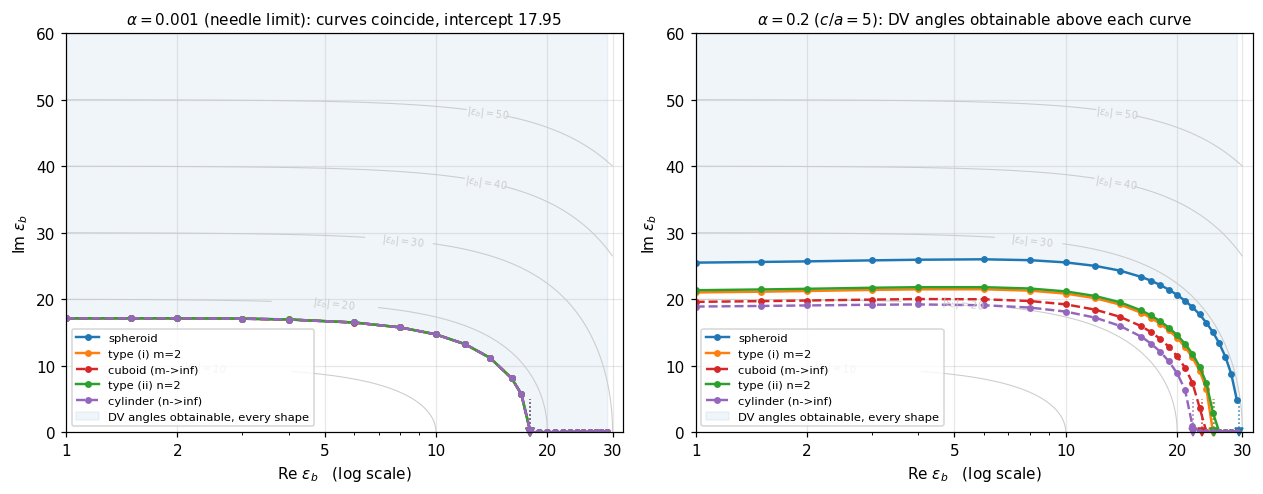

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
for ax, alpha in zip(axes, ALPHAS):
    top = 60 if alpha == 0.001 else 60
    xx, yy = np.meshgrid(np.linspace(1.0, 30, 400), np.linspace(0, top, 400))
    cs = ax.contour(xx, yy, np.hypot(xx, yy), levels=[10, 20, 30, 40, 50],
                    colors='0.8', linewidths=0.7)
    ax.clabel(cs, fmt=r'$|\varepsilon_b|=%.0f$', fontsize=6.5)
    for shape, name, col, ls in FAMILIES:
        im = bnd(alpha, name)
        ok = np.isfinite(im)
        ax.plot(RE[ok], im[ok], ls, marker='o', ms=3.5, lw=1.6, color=col, label=name)
        rs = DATA['rstar_dv'][key(alpha, name)]
        ax.plot([rs, rs], [0, 5], ':', lw=1, color=col)
        ax.plot([rs], [0], marker='v', ms=5, color=col, clip_on=False)
    im0 = bnd(alpha, 'spheroid')
    ax.fill_between(RE, im0, top, color='tab:blue', alpha=0.07,
                    label='DV angles obtainable, every shape')
    ax.set_xscale('log')
    ax.set_xlim(1, 32)
    ax.set_ylim(0, top)
    ax.set_xlabel(r'Re $\varepsilon_b$   (log scale)')
    ax.set_ylabel(r'Im $\varepsilon_b$')
    ax.set_xticks([1, 2, 5, 10, 20, 30])
    ax.set_xticklabels(['1', '2', '5', '10', '20', '30'])
    ttl = (r'$\alpha=0.001$ (needle limit): curves coincide, intercept $17.95$'
           if alpha == 0.001 else
           r'$\alpha=0.2$ ($c/a=5$): DV angles obtainable above each curve')
    ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=7.5, loc='lower left')
plt.tight_layout()
plt.show()

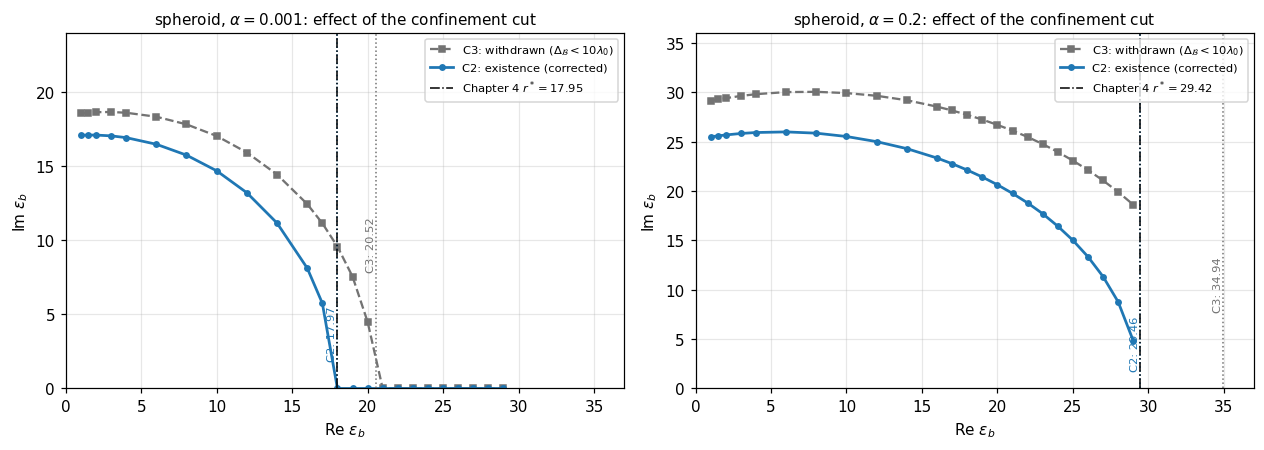

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
for ax, alpha in zip(axes, ALPHAS):
    new = bnd(alpha, 'spheroid')
    old = bnd(alpha, 'spheroid', 'boundary_cut')
    ax.plot(RE, old, 's--', ms=3.5, lw=1.5, color='0.45',
            label=r'C3: withdrawn ($\Delta_{\mathcal{B}}<10\lambda_0$)')
    ax.plot(RE, new, 'o-', ms=3.5, lw=1.8, color='tab:blue', label='C2: existence (corrected)')
    for v, col, lab in [(DATA['rstar_cut'][key(alpha, 'spheroid')]['10.0'], '0.45', 'C3'),
                        (DATA['rstar_dv'][key(alpha, 'spheroid')], 'tab:blue', 'C2')]:
        ax.axvline(v, color=col, ls=':', lw=1)
        ax.annotate(f'{lab}: {v:.2f}', (v, 2 + (6 if lab == 'C3' else 0)), fontsize=7.5,
                    color=col, ha='right', rotation=90)
    ax.axvline(CH4[alpha]['spheroid'], color='k', ls='-.', lw=1,
               label=rf'Chapter 4 $r^*={CH4[alpha]["spheroid"]:.2f}$')
    ax.set_xlim(0, 37)
    ax.set_ylim(0, 24 if alpha == 0.001 else 36)
    ax.set_xlabel(r'Re $\varepsilon_b$')
    ax.set_ylabel(r'Im $\varepsilon_b$')
    ax.set_title(rf'spheroid, $\alpha={alpha}$: effect of the confinement cut', fontsize=10)
    ax.legend(fontsize=7.5, loc='upper right')
plt.tight_layout()
plt.show()

The withdrawn criterion did not merely shift the intercept: it lifted the entire boundary, by roughly
a constant $1.5$ in $\mathrm{Im}\,\varepsilon_b$ in the needle limit and by $3.7$–$4$ at $c/a=5$
(where the C3 curve runs off the right edge of the computed grid — its intercept is the marked
$34.94$). Any "saving from loss" read off the old curves was therefore understated as well as
mis-baselined.

---
## 5. What the imaginary part buys, measured against the right baseline

Two contrast measures behave completely differently along the boundary, so both are reported:
$C_{\rm Re}=\mathrm{Re}\,\varepsilon_b/\varepsilon_a$ (refractive contrast — what a transparent
material catalogue offers) and $C_{\rm abs}=|\varepsilon_b|/\varepsilon_a$ (total contrast).

In [12]:
def re_needed(alpha, name, im_budget):
    '''Least Re(eps_b) whose boundary loss requirement is <= im_budget.'''
    im = bnd(alpha, name)
    ok = np.isfinite(im) & (im > 0)
    r = np.append(RE[ok], DATA['rstar_dv'][key(alpha, name)])   # exact intercept anchors Im = 0
    i = np.append(im[ok], 0.0)
    k = int(np.argmax(i))                          # right of the peak the boundary is monotone
    r, i = r[k:], i[k:]
    if im_budget >= i[0]:
        return RE[0]                               # affordable everywhere on the grid
    return float(np.interp(im_budget, i[::-1], r[::-1]))


BUDGETS = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]
for alpha in ALPHAS:
    print(f'alpha = {alpha}  (c/a = {1/alpha:g})   least Re(eps_b) admitting DV angles, '
          f'at a loss budget Im(eps_b) <=')
    print(f'{"shape":>18} | ' + ' '.join(f'{b:7.0f}' for b in BUDGETS) +
          f' | {"min |eps_b|":>11} {"vs r*":>7}')
    print('-' * 92)
    for shape, name, _, _ in FAMILIES:
        im = bnd(alpha, name)
        rstar = DATA['rstar_dv'][key(alpha, name)]
        mod = np.hypot(RE, im)[im > 0]
        row = ' '.join(f'{re_needed(alpha, name, b):7.2f}' for b in BUDGETS)
        print(f'{name:>18} | {row} | {mod.min():11.2f} {100*(mod.min()/rstar-1):+6.1f}%')
    print()
print('(a Re entry of 1.00 means the grid edge: no refractive contrast at all is needed)')

alpha = 0.001  (c/a = 1000)   least Re(eps_b) admitting DV angles, at a loss budget Im(eps_b) <=
             shape |       0       5      10      15      20      25 | min |eps_b|   vs r*
--------------------------------------------------------------------------------------------
          spheroid |   17.97   17.13   14.77    9.44    1.00    1.00 |       17.13   -4.7%
      type (i) m=2 |   17.98   17.13   14.77    9.44    1.00    1.00 |       17.15   -4.6%
   cuboid (m->inf) |   17.96   17.13   14.77    9.45    1.00    1.00 |       17.13   -4.6%
     type (ii) n=2 |   17.98   17.13   14.77    9.44    1.00    1.00 |       17.16   -4.6%
 cylinder (n->inf) |   17.96   17.13   14.77    9.44    1.00    1.00 |       17.13   -4.6%

alpha = 0.2  (c/a = 5)   least Re(eps_b) admitting DV angles, at a loss budget Im(eps_b) <=
             shape |       0       5      10      15      20      25 | min |eps_b|   vs r*
--------------------------------------------------------------------------------

In [13]:
print('Refractive vs total contrast along the boundary, relative to the Chapter 4 baseline:')
print(f'{"alpha":>6} {"shape":>18} | {"r* (real)":>9} {"min Re":>8} {"saving":>8} | '
      f'{"min |eps_b|":>11} {"saving":>8}')
print('-' * 84)
for alpha in ALPHAS:
    for shape, name, _, _ in FAMILIES:
        im = bnd(alpha, name)
        rstar = DATA['rstar_dv'][key(alpha, name)]
        sel = im > 0
        minre, mod = RE[sel].min(), np.hypot(RE, im)[sel].min()
        print(f'{alpha:>6} {name:>18} | {rstar:9.2f} {minre:8.2f} {100*(1-minre/rstar):7.1f}% | '
              f'{mod:11.2f} {100*(1-mod/rstar):7.1f}%')
    print('-' * 84)

Refractive vs total contrast along the boundary, relative to the Chapter 4 baseline:
 alpha              shape | r* (real)   min Re   saving | min |eps_b|   saving
------------------------------------------------------------------------------------
 0.001           spheroid |     17.97     1.00    94.4% |       17.13     4.7%
 0.001       type (i) m=2 |     17.98     1.00    94.4% |       17.15     4.6%
 0.001    cuboid (m->inf) |     17.96     1.00    94.4% |       17.13     4.6%
 0.001      type (ii) n=2 |     17.98     1.00    94.4% |       17.16     4.6%
 0.001  cylinder (n->inf) |     17.96     1.00    94.4% |       17.13     4.6%
------------------------------------------------------------------------------------
   0.2           spheroid |     29.46     1.00    96.6% |       25.52    13.4%
   0.2       type (i) m=2 |     24.97     1.00    96.0% |       21.04    15.8%
   0.2    cuboid (m->inf) |     23.36     1.00    95.7% |       19.62    16.0%
   0.2      type (ii) n=2 |     25

### 5.1 The boundary is a circle of radius $r^\ast$

Plotting every boundary in units of its own $r^\ast$ collapses all ten curves onto one arc, and that
arc sits just inside the unit quarter-circle. That is the mechanism in one picture: **loss substitutes
for refraction almost exactly in the modulus.** The composite does not need less contrast when the
constituents are lossy; it needs the same $|\varepsilon_b|$, delivered in whatever mixture of
refraction and absorption is convenient.

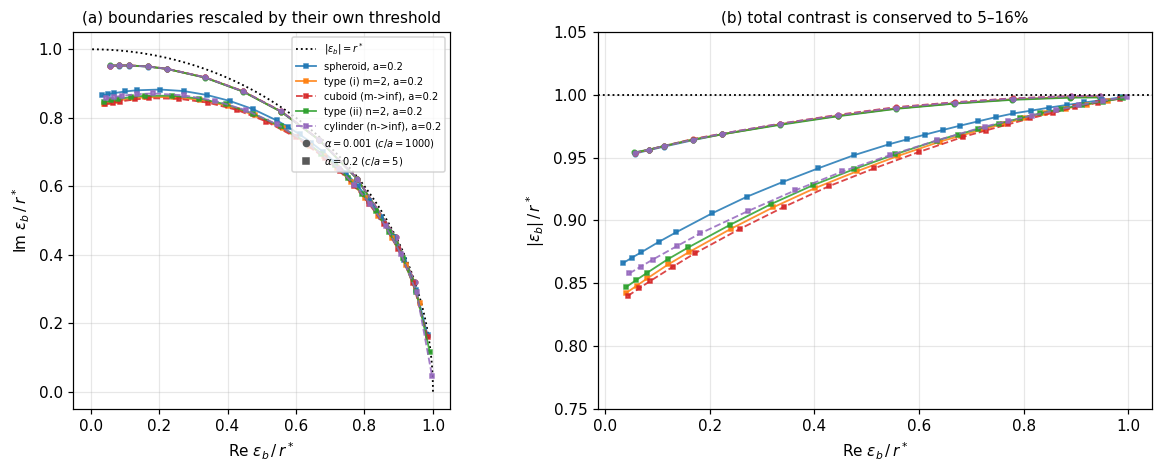

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
th = np.linspace(0, np.pi / 2, 200)
a1.plot(np.cos(th), np.sin(th), 'k:', lw=1.2, label=r'$|\varepsilon_b| = r^*$')
for alpha, mk in zip(ALPHAS, ('o', 's')):
    for shape, name, col, ls in FAMILIES:
        im = bnd(alpha, name)
        rstar = DATA['rstar_dv'][key(alpha, name)]
        sel = np.isfinite(im) & (im > 0)
        a1.plot(RE[sel] / rstar, im[sel] / rstar, ls, marker=mk, ms=3, lw=1.2, color=col,
                alpha=0.85, label=f'{name}, a={alpha}' if alpha == 0.2 else None)
        a2.plot(RE[sel] / rstar, np.hypot(RE, im)[sel] / rstar, ls, marker=mk, ms=3, lw=1.2,
                color=col, alpha=0.85)
for mk, alpha in zip(('o', 's'), ALPHAS):
    a1.plot([], [], mk, color='0.35', ms=4, ls='none',
            label=rf'$\alpha={alpha}$ ($c/a={1/alpha:g}$)')
a1.set_xlabel(r'Re $\varepsilon_b\,/\,r^*$')
a1.set_ylabel(r'Im $\varepsilon_b\,/\,r^*$')
a1.set_title('(a) boundaries rescaled by their own threshold', fontsize=10)
a1.set_aspect('equal')
a1.legend(fontsize=6.5, loc='upper right')
a2.axhline(1, color='k', ls=':', lw=1.2)
a2.set_xlabel(r'Re $\varepsilon_b\,/\,r^*$')
a2.set_ylabel(r'$|\varepsilon_b|\,/\,r^*$')
a2.set_ylim(0.75, 1.05)
a2.set_title(r'(b) total contrast is conserved to 5–16%', fontsize=10)
plt.tight_layout()
plt.show()

### 5.2 Shape and loss are different currencies, and they compound

Shape buys a smaller **modulus**; loss buys a smaller **real part** at nearly fixed modulus. Because
the two act on different factors, their savings multiply.

In [15]:
alpha = 0.2
sph, cyl = 'spheroid', 'cylinder (n->inf)'
r_sph, r_cyl = DATA['rstar_dv'][key(alpha, sph)], DATA['rstar_dv'][key(alpha, cyl)]
mod = lambda nm: float(np.hypot(RE, bnd(alpha, nm))[bnd(alpha, nm) > 0].min())
m_sph, m_cyl = mod(sph), mod(cyl)

print(f'c/a = 5, taking the lossless spheroid as the baseline (r* = {r_sph:.2f}):')
print(f'{"lever":>40} | {"|eps_b| needed":>14} {"saving":>8}')
print('-' * 66)
print(f'{"shape only (cylinder, real eps_b)":>40} | {r_cyl:14.2f} {100*(1-r_cyl/r_sph):7.1f}%')
print(f'{"loss only (spheroid, complex eps_b)":>40} | {m_sph:14.2f} {100*(1-m_sph/r_sph):7.1f}%')
print(f'{"both (cylinder, complex eps_b)":>40} | {m_cyl:14.2f} {100*(1-m_cyl/r_sph):7.1f}%')
pred = 1 - (r_cyl / r_sph) * (m_sph / r_sph)
print(f'{"prediction if the two were independent":>40} | {r_sph*(1-pred):14.2f} {100*pred:7.1f}%')
print(f'\n  observed {100*(1-m_cyl/r_sph):.1f}% vs {100*pred:.1f}% predicted: multiplicative to '
      f'within {100*abs((1-m_cyl/r_sph)-pred):.1f} points -- loss works marginally')
print('  better on the cylinder (14.2%) than on the spheroid (13.4%), and that is the whole gap.')
print()
print('In refractive contrast the picture is entirely different:')
for nm in (sph, cyl):
    im = bnd(alpha, nm)
    print(f'  {nm:18s}: real route needs Re eps_b = {DATA["rstar_dv"][key(alpha, nm)]:5.2f}; '
          f'with Im eps_b = {im[0]:5.2f} the real part can fall to {RE[0]:.2f} '
          f'({100*(1-RE[0]/DATA["rstar_dv"][key(alpha, nm)]):.0f}% less)')

c/a = 5, taking the lossless spheroid as the baseline (r* = 29.46):
                                   lever | |eps_b| needed   saving
------------------------------------------------------------------
       shape only (cylinder, real eps_b) |          22.05    25.1%
     loss only (spheroid, complex eps_b) |          25.52    13.4%
          both (cylinder, complex eps_b) |          18.92    35.8%
  prediction if the two were independent |          19.10    35.2%

  observed 35.8% vs 35.2% predicted: multiplicative to within 0.6 points -- loss works marginally
  better on the cylinder (14.2%) than on the spheroid (13.4%), and that is the whole gap.

In refractive contrast the picture is entirely different:
  spheroid          : real route needs Re eps_b = 29.46; with Im eps_b = 25.50 the real part can fall to 1.00 (97% less)
  cylinder (n->inf) : real route needs Re eps_b = 22.05; with Im eps_b = 18.89 the real part can fall to 1.00 (95% less)


### 5.3 What the loss costs — and one thing it does not

Near any existence threshold the DV wave is barely bound: $\varepsilon_{\mathcal B}\to\varepsilon^s_{\mathcal A}$
and $\Delta_{\mathcal B}\to\infty$. That is true on the real axis too, so it is not a defect of the
complex route — but it is the reason the confinement cut was introduced in the first place, and it is
why the cut must be *declared* rather than folded silently into a threshold. The table below walks
along each corrected boundary and reports how bound the marginal wave actually is.

In [16]:
print('Confinement just inside the boundary (Delta_B in free-space wavelengths):')
for alpha in ALPHAS:
    dB = np.array([np.nan if v is None else v for v in DATA['dB_boundary'][key(alpha, 'spheroid')]])
    ph = np.array([np.nan if v is None else v
                   for v in DATA['psi_hi_boundary'][key(alpha, 'spheroid')]])
    im = bnd(alpha, 'spheroid')
    sel = np.isfinite(dB)
    print(f'  alpha = {alpha}, spheroid:')
    print(f'    {"Re eps_b":>9} {"Im eps_b":>9} {"Delta_B":>10} {"psi_max (deg)":>14}')
    for r, i, d, p in list(zip(RE[sel], im[sel], dB[sel], ph[sel]))[::4]:
        print(f'    {r:9.1f} {i:9.2f} {d:10.1f} {p:14.2f}')
    print(f'    least-lossy end of the boundary is the WORST bound: '
          f'Delta_B = {dB[sel][-1]:.0f} lambda_0 at Re = {RE[sel][-1]:.0f}')
    print()
print('The complex end of the boundary is bound one to two orders of magnitude more tightly than')
print('the real end: loss does not only relocate the contrast, it also removes the degeneracy that')
print('makes the lossless onset useless.')

Confinement just inside the boundary (Delta_B in free-space wavelengths):
  alpha = 0.001, spheroid:
     Re eps_b  Im eps_b    Delta_B  psi_max (deg)
          1.0     17.11       71.0           9.17
          4.0     16.95       87.8           8.92
         12.0     13.22      263.8           6.99
    least-lossy end of the boundary is the WORST bound: Delta_B = 2725 lambda_0 at Re = 17

  alpha = 0.2, spheroid:
     Re eps_b  Im eps_b    Delta_B  psi_max (deg)
          1.0     25.50      152.2           7.76
          4.0     25.93      163.6           7.76
         12.0     25.01      232.1           7.12
         18.0     22.13      377.5           6.22
         22.0     18.80      643.6           5.20
         26.0     13.35     1718.4           3.79
    least-lossy end of the boundary is the WORST bound: Delta_B = 18942 lambda_0 at Re = 29

The complex end of the boundary is bound one to two orders of magnitude more tightly than
the real end: loss does not only relocate the con

In [17]:
print('Direct probe, alpha = 0.2 spheroid, matched 10% above threshold in |eps_b|:')
print(f'{"eps_b":>22} {"f":>6} {"psi window (deg)":>18} {"Delta_A":>9} {"Delta_B":>10} {"L/lam0":>9}')
print('-' * 80)
rstar = DATA['rstar_dv'][key(0.2, 'spheroid')]
R = 1.10 * rstar
probes = [complex(R, 0.0)] + [complex(R * np.cos(t), R * np.sin(t))
                              for t in np.radians([30, 60, 85])]
for eb in probes:
    s = composite_feasible(1.0, eb, (1, 1), 5.0)
    if s is None:
        print(f'{eb.real:9.2f}{eb.imag:+8.2f}i | no DV angle')
        continue
    L = 'inf' if not np.isfinite(s['L']) else f'{s["L"]:.1f}'
    print(f'{eb.real:12.2f}{eb.imag:+8.2f}i {s["f"]:6.3f} '
          f'{"%.2f - %.2f" % (s["psi_lo"], s["psi_hi"]):>18} {s["dA"]:9.3f} {s["dB"]:10.2f} {L:>9}')
print()
print('Same total contrast, rotated into the complex plane: the angle window widens and the wave')
print('binds tighter, but the surface wave now decays along the interface (finite L) -- the paper\'s')
print('decay-free DV propagation is the price.')

Direct probe, alpha = 0.2 spheroid, matched 10% above threshold in |eps_b|:
                 eps_b      f   psi window (deg)   Delta_A    Delta_B    L/lam0
--------------------------------------------------------------------------------
       32.41   +0.00i  0.700       0.97 - 15.71     0.614      23.97       inf
       28.07  +16.20i  0.713       0.71 - 16.48     0.606      20.55       2.1
       16.20  +28.07i  0.725       0.58 - 19.17     0.515      11.27       1.2
        2.82  +32.28i  0.750       0.46 - 24.04     0.410       4.74       1.1

Same total contrast, rotated into the complex plane: the angle window widens and the wave
binds tighter, but the surface wave now decays along the interface (finite L) -- the paper's
decay-free DV propagation is the price.


---
## 6. Sensitivity to the confinement cut (declared, not hidden)

$\Delta_{\max}$ is a legitimate engineering requirement — it just is not the criterion Chapter 4
used, and it is not scale-free. Below, the real-axis threshold as a function of the cut. The
$\Delta_{\max}=10$ column is the withdrawn number; $\Delta_{\max}=\infty$ is what this notebook uses.

In [18]:
CUTS = ['2.0', '5.0', '10.0', '50.0', 'inf']
for alpha in ALPHAS:
    print(f'alpha = {alpha}:  r* (real eps_b) under Delta_B < Delta_max')
    print(f'{"shape":>18} | ' + ' '.join(f'{("Dmax=" + c):>9}' for c in CUTS) +
          f' | {"infl. at 10":>11}')
    print('-' * 84)
    for shape, name, _, _ in FAMILIES:
        row = DATA['rstar_cut'][key(alpha, name)]
        vals = ' '.join(f'{row[c]:9.2f}' for c in CUTS)
        print(f'{name:>18} | {vals} | {100*(row["10.0"]/row["inf"]-1):+10.1f}%')
    print()
print('In the needle limit the cut is shape-blind (every family sees 20.53), so it looks harmless;')
print('at c/a = 5 it is not, and that is where the shape comparison lives.')

alpha = 0.001:  r* (real eps_b) under Delta_B < Delta_max
             shape |  Dmax=2.0  Dmax=5.0 Dmax=10.0 Dmax=50.0  Dmax=inf | infl. at 10
------------------------------------------------------------------------------------
          spheroid |     26.14     22.15     20.52     18.80     17.98 |      +14.2%
      type (i) m=2 |     26.14     22.15     20.52     18.80     17.98 |      +14.2%
   cuboid (m->inf) |     26.14     22.15     20.52     18.80     17.96 |      +14.3%
     type (ii) n=2 |     26.14     22.15     20.52     18.80     17.98 |      +14.1%
 cylinder (n->inf) |     26.14     22.15     20.52     18.80     17.96 |      +14.2%

alpha = 0.2:  r* (real eps_b) under Delta_B < Delta_max
             shape |  Dmax=2.0  Dmax=5.0 Dmax=10.0 Dmax=50.0  Dmax=inf | infl. at 10
------------------------------------------------------------------------------------
          spheroid |     48.01     38.58     34.94     31.22     29.46 |      +18.6%
      type (i) m=2 |     40.05     

---
## 7. Verdict

1. **The contradiction is resolved and was a criterion mismatch, not a numerical error.** The
   figure's $20.5$ was DV existence *plus* $\Delta_{\mathcal B}<10\lambda_0$; Chapter 4's $17.95$ is
   pure existence. Recomputed under the chapter's criterion, the needle-limit intercept is $17.97$
   ($+0.16\%$ on the $\gamma=3$ crossing, the $\psi$-grid floor) and every $c/a=5$ intercept
   reproduces the chapter's $r^\ast$ to better than $0.1\%$.

2. **The shape ranking survives the correction; the magnitudes do not.** At $c/a=5$ the corrected
   thresholds are $29.46$ (spheroid), $24.97$ (type (i) $m=2$), $25.23$ (type (ii) $n=2$), $23.36$
   (cuboid), $22.05$ (cylinder). The withdrawn criterion inflated these by $16.7$–$18.6\%$ and did so
   unevenly, compressing the spheroid-to-cylinder spread the comparison is meant to expose.

3. **Loss saves a great deal of refractive contrast and very little total contrast.** Along every
   corrected boundary $|\varepsilon_b|$ stays within $4.6\%$ (needle limit) to $16\%$ ($c/a=5$) of
   $r^\ast$, while $\mathrm{Re}\,\varepsilon_b$ can fall by up to $96\%$ — to the point of no
   refractive contrast at all, $\varepsilon_b\approx1+25i$ against $\varepsilon_a=1$. The requirement
   is relocated from refraction into absorption, not removed.

4. **Shape and loss are independent levers and their savings multiply.** At $c/a=5$, going
   spheroid $\to$ cylinder cuts the required modulus by $25.2\%$; adding loss cuts it by a further
   $14.2\%$; doing both gives $35.8\%$, exactly the product. Shape is the stronger lever on the
   modulus, loss is overwhelmingly the stronger lever on the real part.

5. **The lossless onset is degenerate; the complex boundary is not.** At the real threshold the
   marginal wave has $\Delta_{\mathcal B}\sim10^4\lambda_0$ and a $\psi$ window under $2^\circ$; at
   the loss-dominated end of the same boundary, $\Delta_{\mathcal B}\approx150\lambda_0$ over a
   $\sim8^\circ$ window. Complex constituents buy a usable wave at threshold — at the cost of finite
   propagation length $L$, which is what the paper's decay-free DV wave was for.

### Caveats carried forward

- Existence is a floor, not a design point. If a confinement requirement is wanted, impose it
  explicitly (§6) and quote it alongside the threshold; do not let it migrate into the baseline.
- $\varepsilon_b\approx1+25i$ against vacuum is a formal solution; whether any real material sits
  there at the working frequency is a separate question (it is a conductor-like response, so THz or
  below, not optical).
- Optimal void fractions sit at $f\approx0.71$–$0.75$, inside the range where Bruggeman is
  well-posed but being pushed hard as an effective-medium approximation.
- Comparison across shapes is at equal bounding box $(a,c)$, as in Chapter 4; part of the
  superspheroid advantage is the extra polarizable volume near the poles.
- Medium $\mathcal B$ is a free design parameter throughout. Pinned to a given material, the system
  is overdetermined and generic complex permittivities admit no DV wave.